In [195]:
# Necessitites
# !pip install missingno

import missingno as msno
import json

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt


In [196]:
"""
Data sample :
{
  "overall": 5,
  "verified": true,
  "reviewTime": "08 4, 2014",
  "reviewerID": "A24E3SXTC62LJI",
  "asin": "7508492919",
  "style": {
    "Color:": " Bling"
  },
  "reviewerName": "Claudia Valdivia",
  "reviewText": "Looks even better in person. Be careful to not drop your phone so often because the rhinestones will fall off (duh). More of a decorative case than it is protective, but I will say that it fits perfectly and securely on my phone. Overall, very pleased with this purchase.",
  "summary": "Can't stop won't stop looking at it",
  "unixReviewTime": 1407110400
}
"""

'\nData sample : \n{\n  "overall": 5,\n  "verified": true,\n  "reviewTime": "08 4, 2014",\n  "reviewerID": "A24E3SXTC62LJI",\n  "asin": "7508492919",\n  "style": {\n    "Color:": " Bling"\n  },\n  "reviewerName": "Claudia Valdivia",\n  "reviewText": "Looks even better in person. Be careful to not drop your phone so often because the rhinestones will fall off (duh). More of a decorative case than it is protective, but I will say that it fits perfectly and securely on my phone. Overall, very pleased with this purchase.",\n  "summary": "Can\'t stop won\'t stop looking at it",\n  "unixReviewTime": 1407110400\n}\n'

In [197]:
FILE_PATH = "/content/Cell_Phones_and_Accessories_5.json"

In [198]:
# Iterative parsing of json data
reviews = []

# Only keep what you need from the start
KEEP_COLUMNS = {'asin', 'reviewText', 'overall', 'reviewerName',
                'reviewTime', 'verified', 'summary'}



with open(FILE_PATH, 'r', encoding='utf-8') as f:
    for line_num, line in enumerate(f, 1):
        # Remove trailing whitespaces or newlines (\n)
        cleaned_line = line.strip()

        # Skip empty lines completely
        if not cleaned_line:
            continue

        try:
            raw = json.loads(cleaned_line)
            reviews.append({k: v for k, v in raw.items() if k in KEEP_COLUMNS})
        except json.JSONDecodeError:
            # Captures and skips any hidden corrupt formatting lines
            print(f"Skipped broken formatting on line {line_num}")

# Convert the successfully read records into your DataFrame
df = pd.DataFrame(reviews)
print("Data loaded successfully! Table shape:", df.shape)



Skipped broken formatting on line 1041269
Data loaded successfully! Table shape: (1041268, 7)


In [199]:
df.head()

,overall,verified,reviewTime,asin,reviewerName,reviewText,summary
0,5.0,True,"08 4, 2014",7508492919,Claudia Valdivia,Looks even better in person. Be careful to not...,Can't stop won't stop looking at it
1,5.0,True,"02 12, 2014",7508492919,sarah ponce,When you don't want to spend a whole lot of ca...,1
2,3.0,True,"02 8, 2014",7508492919,Kai,"so the case came on time, i love the design. I...",Its okay
3,2.0,True,"02 4, 2014",7508492919,Sharon Williams,DON'T CARE FOR IT. GAVE IT AS A GIFT AND THEY...,CASE
4,4.0,True,"02 3, 2014",7508492919,Bella Rodriguez,"I liked it because it was cute, but the studs ...",Cute!


In [200]:
df.tail()

,overall,verified,reviewTime,asin,reviewerName,reviewText,summary
1041263,5.0,True,"12 22, 2014",B005ZG043C,Gayle,Great case it has held up real good! I love t...,Great case it has held up real good
1041264,3.0,True,"11 30, 2014",B005ZG043C,Pixie Girl,Nice quality case but the white really gets di...,Nice case...But don't get white.
1041265,5.0,True,"07 8, 2015",B005ZHUP2G,Carl Jean-Richard Otello,great,Five Stars
1041266,3.0,True,"03 10, 2015",B005ZHUP2G,Jesus,BUENO,Three Stars
1041267,4.0,True,"08 28, 2014",B005ZHUP2G,juanchoo,Great buy,Four Stars


In [201]:
df.sample(5)

,overall,verified,reviewTime,asin,reviewerName,reviewText,summary
479800,5.0,True,"05 6, 2015",B00LTTK092,gustavo,good,Five Stars
705,1.0,True,"02 20, 2018",B0001J3UWU,Happy Shopper,Sorry to say that the product didn't even char...,Didn't work
992318,5.0,True,"07 11, 2016",B01EPYAPWY,A. Baez,If you were looking for a harder TPU this is n...,May be to soft for some.
697522,5.0,True,"08 17, 2015",B00V0EC1OS,Lorena,Super cute!,Five Stars
833972,2.0,True,"12 6, 2015",B014GGB02K,Julie,"The Galaxy Note 5, even in an Incipio case, fi...",the belt clip that slips on over your belt str...


In [202]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1041268 entries, 0 to 1041267
Data columns (total 7 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   overall       1041268 non-null  float64
 1   verified      1041268 non-null  bool   
 2   reviewTime    1041268 non-null  object 
 3   asin          1041268 non-null  object 
 4   reviewerName  1041144 non-null  object 
 5   reviewText    1040636 non-null  object 
 6   summary       1040809 non-null  object 
dtypes: bool(1), float64(1), object(5)
memory usage: 581.0 MB


In [203]:
# There are some missing reviews here too ;need to check them later.

In [204]:
df.isna().sum()

,0
overall,0
verified,0
reviewTime,0
asin,0
reviewerName,124
reviewText,632
summary,459


In [205]:
# No of missing values are negligible here and can be dropped as it is way less than the actual dataset size.

In [206]:
# But still look at the pattern to understand more

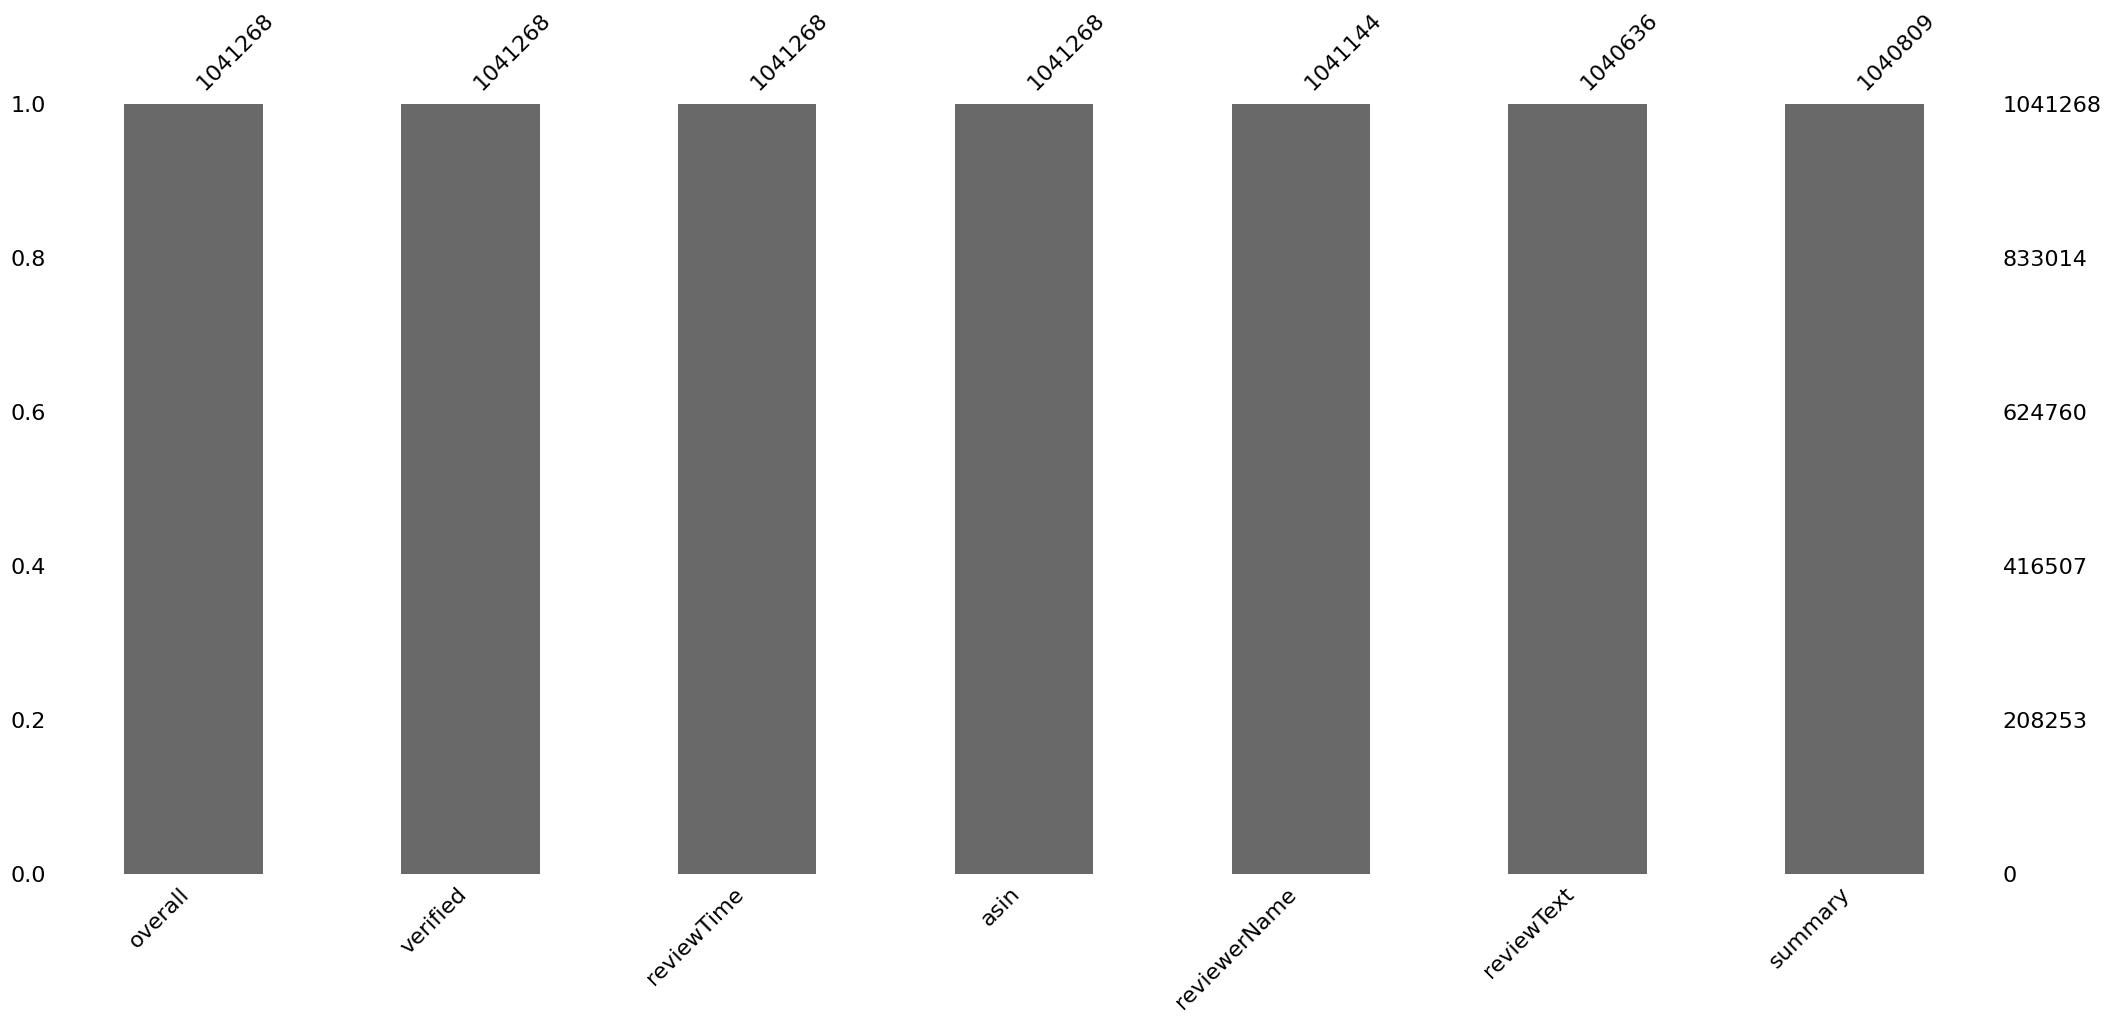

In [207]:
msno.bar(df)
plt.show()

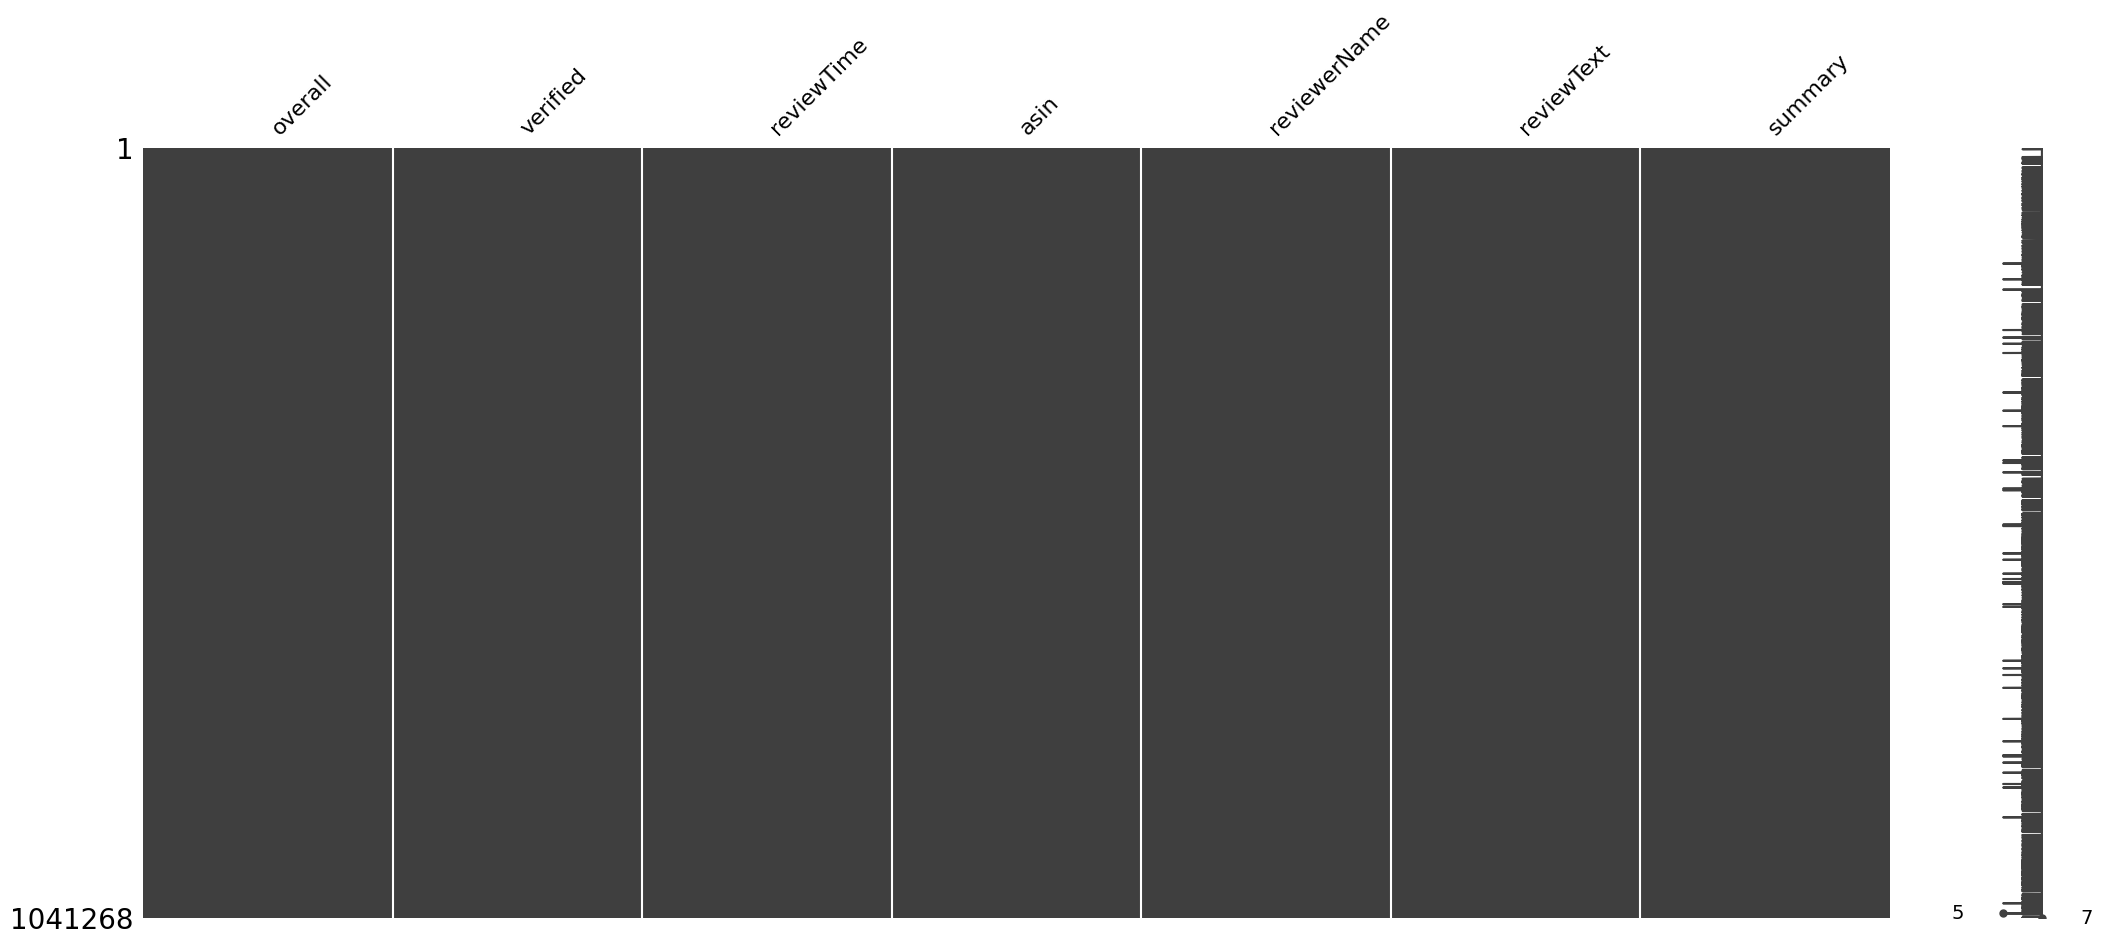

In [208]:
msno.matrix(df)
plt.show()

In [209]:
# As expected the missing data is so less that it does not even show in the graph .

In [210]:
# Returns rows where any of the columns contain an NA value
df[df.isna().any(axis=1)]

,overall,verified,reviewTime,asin,reviewerName,reviewText,summary
1665,5.0,True,"06 12, 2009",B0009B0IX4,NaN,The Plantronics Voyager 510 Bluetooth Headset ...,Just About Perfect
12212,5.0,True,"12 22, 2008",B001B15AVQ,NaN,"In this age where Bluetooth, WiFi, touchscreen...",Best Deal Around
12215,4.0,True,"10 18, 2009",B001B15AVQ,NaN,"In this age where Bluetooth, WiFi, touchscreen...",Not A Bad Deal Overall
13591,1.0,True,"08 17, 2014",B001ETRNAQ,Sherry Harrison,NaN,One Star
14013,5.0,True,"10 29, 2017",B001FVQ4TY,ot,NaN,Five Stars
...,...,...,...,...,...,...,...
1035656,5.0,True,"07 25, 2016",B004PBBSWO,silas,NaN,Five Stars
1036364,5.0,True,"04 22, 2015",B004WMDTHS,Carla J Sandy,NaN,Five Stars
1040442,5.0,True,"11 29, 2014",B005SMLF54,Michele,NaN,Five Stars
1040780,5.0,True,"02 29, 2016",B005VNJZ0C,Kelly,NaN,Five Stars


In [211]:
# There are 1171 rows missing ; which are negligible

In [212]:
1171/len(df) # The no of rows missing is negligilbe and can be skipped

0.0011245904032391276

In [213]:
# So in the major pipeline we can discard these rows

In [214]:
df = df.dropna()

In [215]:
df

,overall,verified,reviewTime,asin,reviewerName,reviewText,summary
0,5.0,True,"08 4, 2014",7508492919,Claudia Valdivia,Looks even better in person. Be careful to not...,Can't stop won't stop looking at it
1,5.0,True,"02 12, 2014",7508492919,sarah ponce,When you don't want to spend a whole lot of ca...,1
2,3.0,True,"02 8, 2014",7508492919,Kai,"so the case came on time, i love the design. I...",Its okay
3,2.0,True,"02 4, 2014",7508492919,Sharon Williams,DON'T CARE FOR IT. GAVE IT AS A GIFT AND THEY...,CASE
4,4.0,True,"02 3, 2014",7508492919,Bella Rodriguez,"I liked it because it was cute, but the studs ...",Cute!
...,...,...,...,...,...,...,...
1041263,5.0,True,"12 22, 2014",B005ZG043C,Gayle,Great case it has held up real good! I love t...,Great case it has held up real good
1041264,3.0,True,"11 30, 2014",B005ZG043C,Pixie Girl,Nice quality case but the white really gets di...,Nice case...But don't get white.
1041265,5.0,True,"07 8, 2015",B005ZHUP2G,Carl Jean-Richard Otello,great,Five Stars
1041266,3.0,True,"03 10, 2015",B005ZHUP2G,Jesus,BUENO,Three Stars


In [216]:
df['overall'].value_counts()

,count
overall,
5.0,654523
4.0,170254
3.0,89272
1.0,74037
2.0,52011


In [217]:
# As expected this is imbalanced too.

In [218]:
# In a typical machine learning project we would have converted the reviewTime to Date format , but as we dont use it we wont .

In [220]:
df['reviewerName'].value_counts()

,count
reviewerName,
Amazon Customer,33971
Kindle Customer,3082
John,1568
Chris,1463
Mike,1457
...,...
Pinkkita,1
Burbon,1
Oscar M. Ordonez,1


In [221]:
# So yeah as we can see that there are many customers with unqique names and many with the common names
# But the most popular name is Amazon Customer or Kindle Customer : Possible users which do not want to disclose their name for Privacy

In [223]:
(df['reviewText'].str.len().describe())  # review length stats

,reviewText
count,1.040097e+06
mean,2.772491e+02
std,5.192858e+02
min,1.000000e+00
25%,4.100000e+01
50%,1.250000e+02
75%,2.980000e+02
max,3.345700e+04


In [224]:
# So minimum review length is of 1 character and maximum one is having like 33457 characters in it .

In [228]:
df[df['reviewText'].str.len() < 20]

,overall,verified,reviewTime,asin,reviewerName,reviewText,summary
102,4.0,True,"06 8, 2015",8288862993,Robert Valadez,Good product,Four Stars
103,4.0,True,"06 3, 2015",8288862993,Michael,Works as advertised,Four Stars
110,5.0,True,"10 19, 2014",8288862993,John,Works great!!,Five Stars
111,5.0,True,"10 22, 2015",8288878881,Mz Tee,Good item,Five Stars
112,5.0,True,"10 20, 2015",8288878881,KEH,very good price.,Five Stars
...,...,...,...,...,...,...,...
1041256,5.0,True,"01 24, 2016",B005ZG080Q,ALI,Thank you,Five Stars
1041259,4.0,True,"01 8, 2015",B005ZG060S,lugnuts,Good Case,Four Stars
1041265,5.0,True,"07 8, 2015",B005ZHUP2G,Carl Jean-Richard Otello,great,Five Stars
1041266,3.0,True,"03 10, 2015",B005ZHUP2G,Jesus,BUENO,Three Stars


In [229]:
# Maybe what we can do is keep a threshold amount characters / a single word to accept from the user before making predictions to make sure we don't make False or hallucinated predictions , improving model performance.